In [314]:
from typing import Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt

def plot_3d_surface(
    x: np.ndarray,
    t: np.ndarray,
    U: np.ndarray,
    title: str,
    filename: Optional[str] = None,
    cmap: str = 'viridis',
    azim: int = -60
) -> Tuple[plt.Figure, plt.Axes]:
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    X, T_grid = np.meshgrid(x, t)
    surf = ax.plot_surface(X, T_grid, U, cmap=cmap, edgecolor='none', alpha=0.9)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('t', fontsize=12)
    ax.set_zlabel('U(x,t)', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.view_init(elev=25, azim=azim)
    cbar = fig.colorbar(surf, ax=ax, shrink=0.6)
    cbar.set_label('U(x,t)', rotation=270, labelpad=15)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    return fig, ax

def plot_time_snapshots(
    x_coords: list,
    t_coords: list,
    u_solution: list,
    num_snapshots: int = 5,
    title: str = "Эволюция решения во времени"
):
    plt.figure(figsize=(12, 7))
    num_time_steps = len(u_solution)
    snapshot_indices = np.linspace(0, num_time_steps - 1, num=num_snapshots, dtype=int)

    for j in snapshot_indices:
        time_moment = t_coords[j]
        solution_at_time_j = u_solution[j]

        plt.plot(x_coords, solution_at_time_j, label=f't = {time_moment:.3f} c')

    plt.title(title, fontsize=16)
    plt.xlabel("Координата x", fontsize=12)
    plt.ylabel("Значение u", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title="Моменты времени", fontsize=10)
    plt.show()


In [315]:
def artificial_viscosity(x: list[float], t: list[float], eps: float, h: float, tau: float) -> list[list[float]]:
    nx = len(x)
    nt = len(t)

    u = [([0] * nx) for _ in range(nt)]

    for i in range(nx):
        xi = x[i]
        u[0][i] = u0_left if xi < 1/2 else u0_right

    for j in range(nt - 1):
        tj = t[j]

        u[j + 1][0] = u0_left

        for i in range(1, nx - 1):
            u[j + 1][i] = u[j][i] - tau/h * u[j][i] * (u[j][i] - u[j][i - 1]) - eps ** 2 * tau / (2 * h ** 3) * (u[j][i + 1] - u[j][i - 1]) * (u[j][i + 1] - 2* u[j][i] + u[j][i - 1])

        u[j + 1][nx - 1] = u[j + 1][nx - 2]

    return u

In [316]:
def conservative_scheme(x: list[float], t: list[float], h: float, tau: float) -> list[list[float]]:
    nx = len(x)
    nt = len(t)

    u = [([0] * nx) for _ in range(nt)]

    for i in range(nx):
        xi = x[i]
        u[0][i] = u0_left if xi < 1 / 2 else u0_right

    for j in range(nt - 1):
        tj = t[j]

        u[j + 1][0] = u0_left

        for i in range(1, nx):
            u[j + 1][i] = u[j][i] - tau / (2 * h) * (u[j][i] ** 2 - u[j][i - 1] ** 2)

    return u

In [317]:
a = c = 0
b = d = 1

In [318]:
u0_left = 2
u0_right = 1

In [319]:
eps = 1e-2
h = 0.1
tau = h / 100
nx = int((b - a) / h + 1)
nt = int((d - c) / tau + 1)

x = [a + i * h for i in range(nx)]
t = [c + i * tau for i in range(nt)]

u = artificial_viscosity(x, t, eps, h, tau)

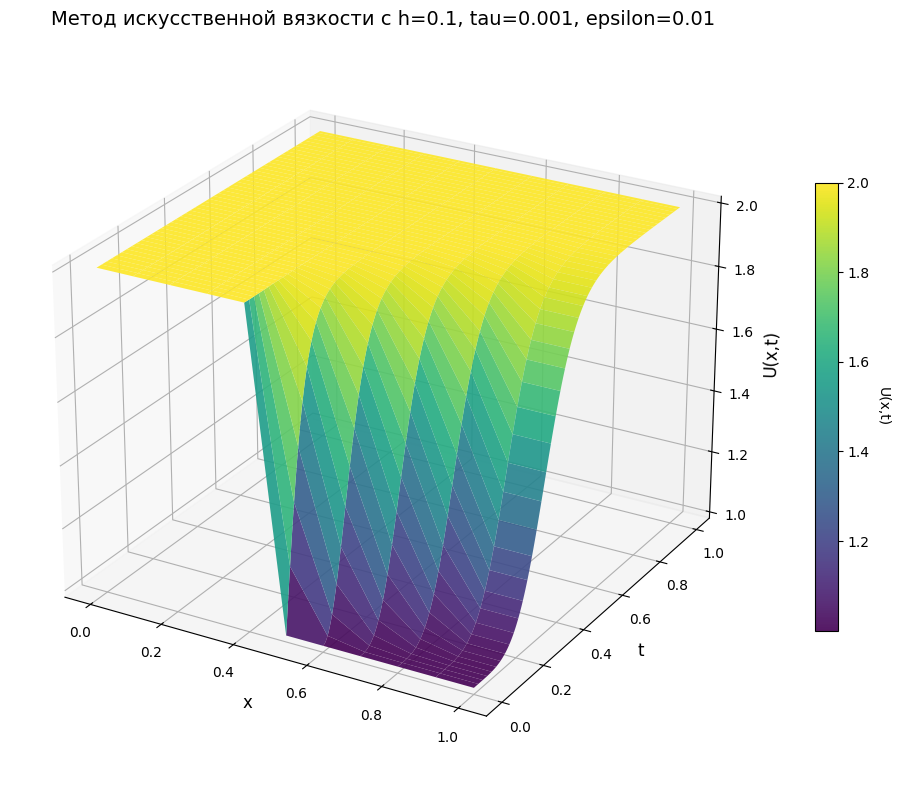

(<Figure size 1200x800 with 2 Axes>,
 <Axes3D: title={'center': 'Метод искусственной вязкости с h=0.1, tau=0.001, epsilon=0.01'}, xlabel='x', ylabel='t', zlabel='U(x,t)'>)

In [320]:
plot_3d_surface(
    np.array(x),
    np.array(t),
    np.array(u),
    "Метод искусственной вязкости с h=0.1, tau=0.001, epsilon=0.01",
    filename="Метод искусственной вязкости с h=0.1, tau=0.001, epsilon=0.01.png"
)

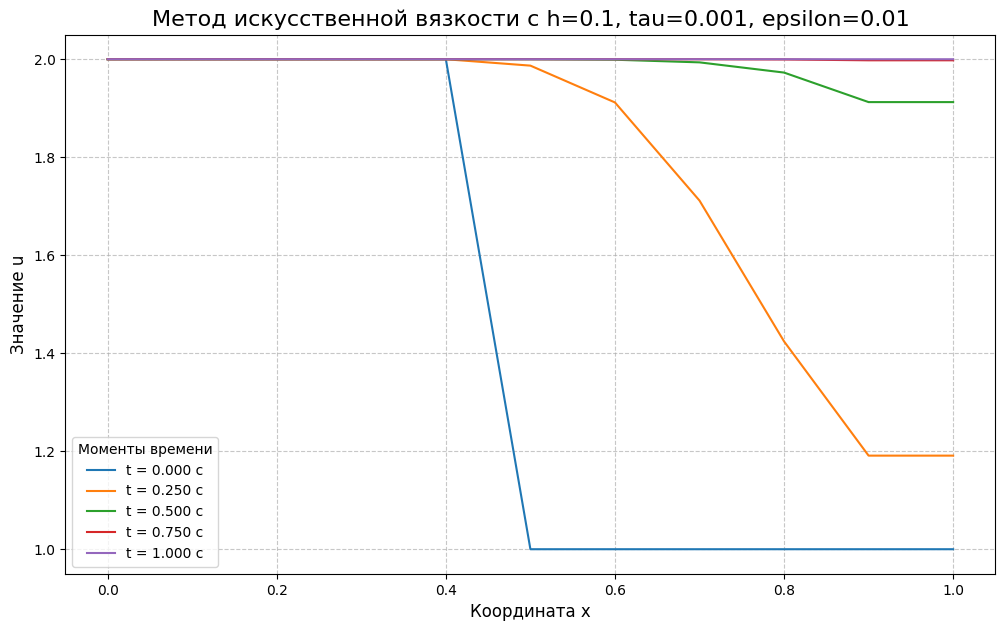

In [321]:
plot_time_snapshots(x_coords=x, t_coords=t, u_solution=u, title="Метод искусственной вязкости с h=0.1, tau=0.001, epsilon=0.01")

In [322]:
eps = 1e-3
h = 0.05
tau = h/100
nx = int((b - a) / h + 1)
nt = int((d - c) / tau + 1)

x = [a + i * h for i in range(nx)]
t = [c + i * tau for i in range(nt)]

u = artificial_viscosity(x, t, eps, h, tau)

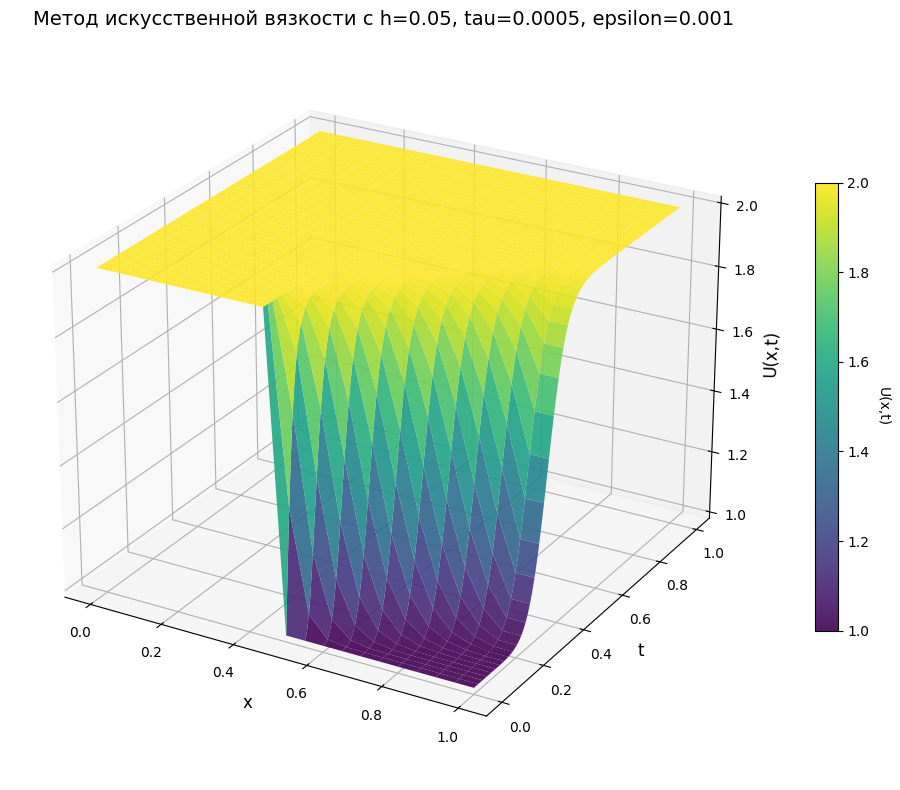

(<Figure size 1200x800 with 2 Axes>,
 <Axes3D: title={'center': 'Метод искусственной вязкости с h=0.05, tau=0.0005, epsilon=0.001'}, xlabel='x', ylabel='t', zlabel='U(x,t)'>)

In [323]:
plot_3d_surface(
    np.array(x),
    np.array(t),
    np.array(u),
    "Метод искусственной вязкости с h=0.05, tau=0.0005, epsilon=0.001",
    filename="Метод искусственной вязкости с h=0.05, tau=0.0005, epsilon=0.001.png"
)

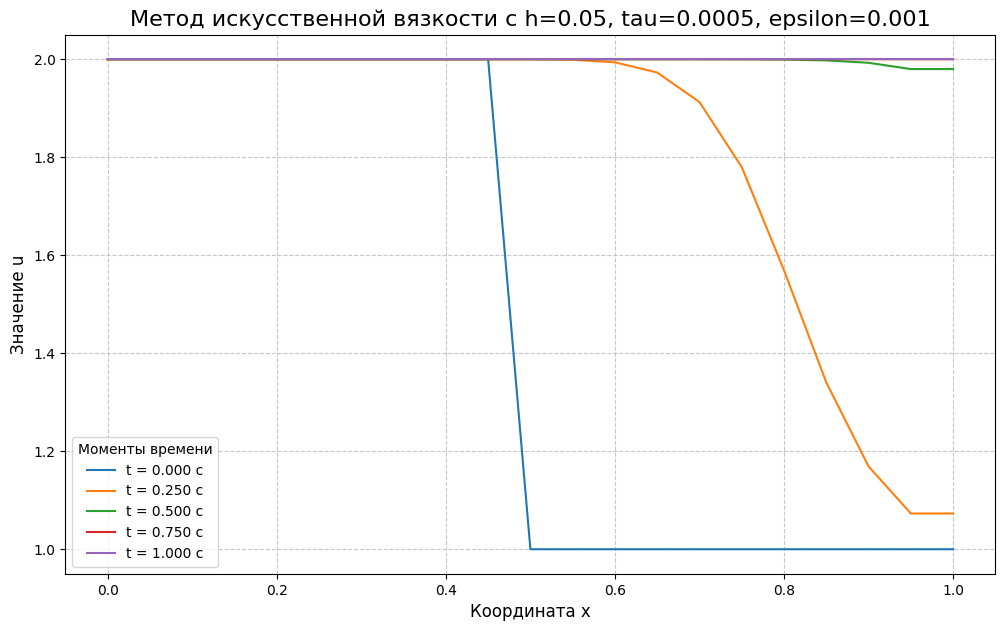

In [324]:
plot_time_snapshots(x_coords=x, t_coords=t, u_solution=u, title="Метод искусственной вязкости с h=0.05, tau=0.0005, epsilon=0.001")

In [325]:
eps = 1e-4
h = 0.025
tau = h / 100
nx = int((b - a) / h + 1)
nt = int((d - c) / tau + 1)

x = [a + i * h for i in range(nx)]
t = [c + i * tau for i in range(nt)]

u = artificial_viscosity(x, t, eps, h, tau)

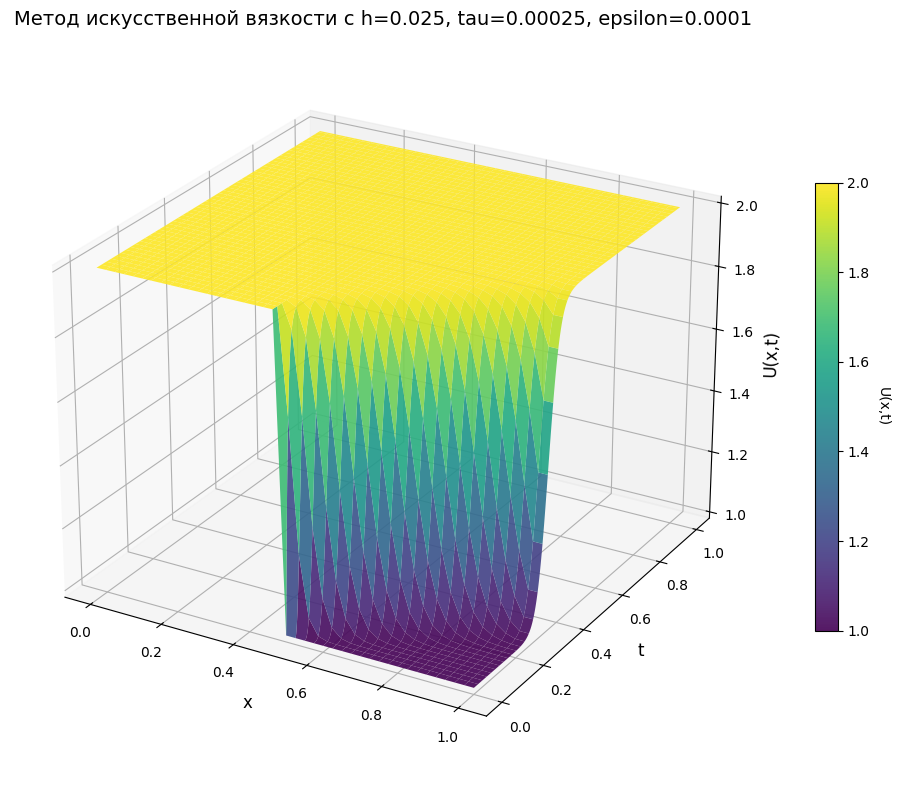

(<Figure size 1200x800 with 2 Axes>,
 <Axes3D: title={'center': 'Метод искусственной вязкости с h=0.025, tau=0.00025, epsilon=0.0001'}, xlabel='x', ylabel='t', zlabel='U(x,t)'>)

In [326]:
plot_3d_surface(
    np.array(x),
    np.array(t),
    np.array(u),
    "Метод искусственной вязкости с h=0.025, tau=0.00025, epsilon=0.0001",
    filename="Метод искусственной вязкости с h=0.025, tau=0.00025, epsilon=0.0001.png"
)

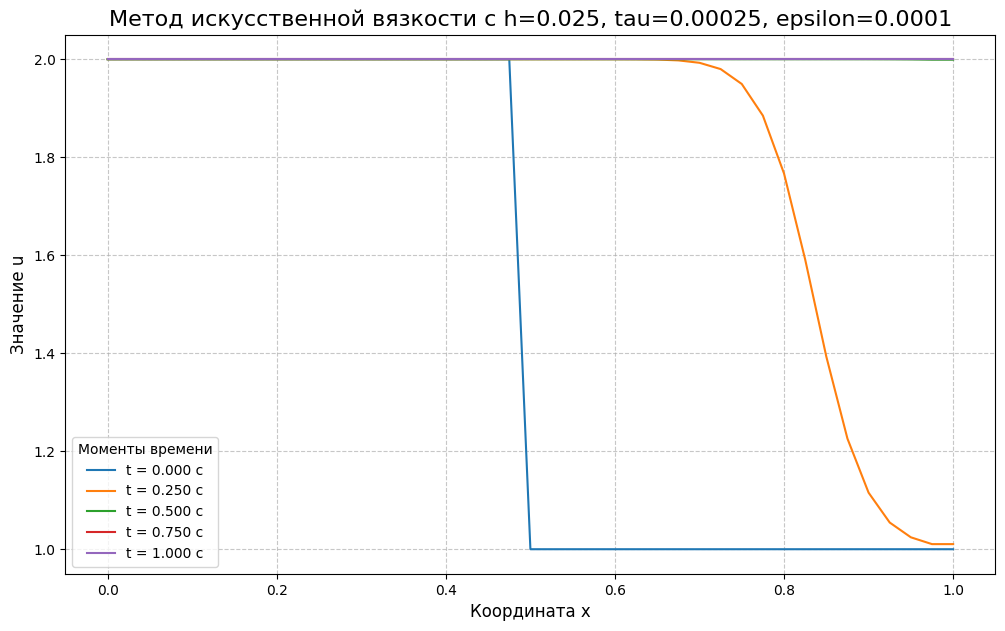

In [327]:
plot_time_snapshots(x_coords=x, t_coords=t, u_solution=u, title="Метод искусственной вязкости с h=0.025, tau=0.00025, epsilon=0.0001")

In [328]:
h = 0.1
tau = h / 100
nx = int((b - a) / h + 1)
nt = int((d - c) / tau + 1)

x = [a + i * h for i in range(nx)]
t = [c + i * tau for i in range(nt)]

u = conservative_scheme(x, t, h, tau)

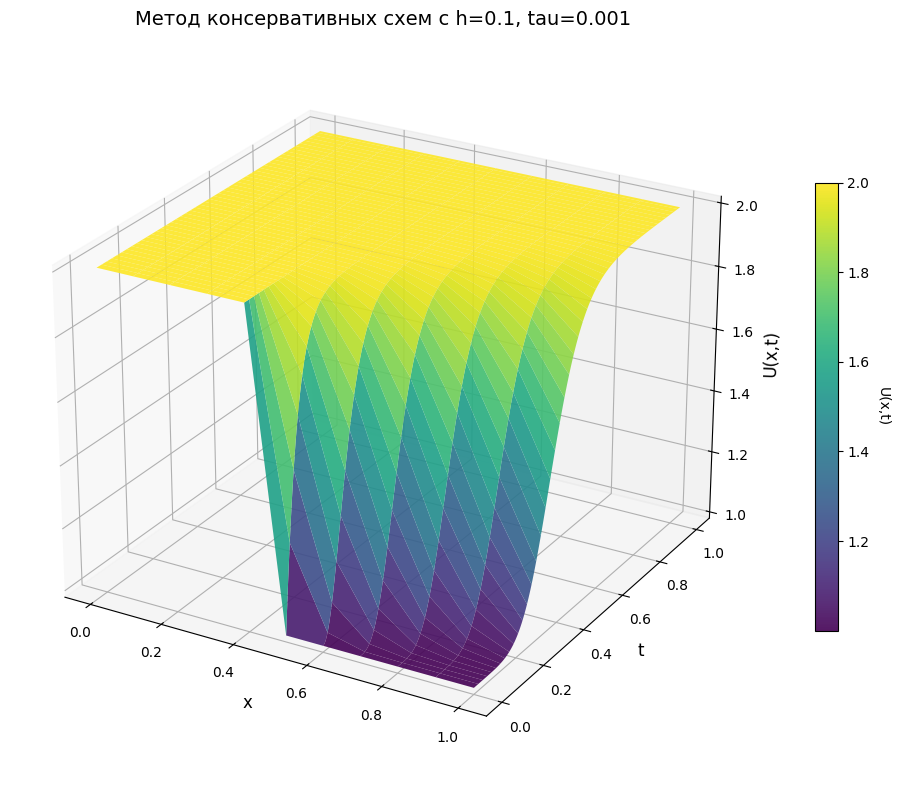

(<Figure size 1200x800 with 2 Axes>,
 <Axes3D: title={'center': 'Метод консервативных схем с h=0.1, tau=0.001'}, xlabel='x', ylabel='t', zlabel='U(x,t)'>)

In [329]:
plot_3d_surface(
    np.array(x),
    np.array(t),
    np.array(u),
    "Метод консервативных схем с h=0.1, tau=0.001",
    filename="Метод консервативных схем с h=0.1, tau=0.001.png"
)

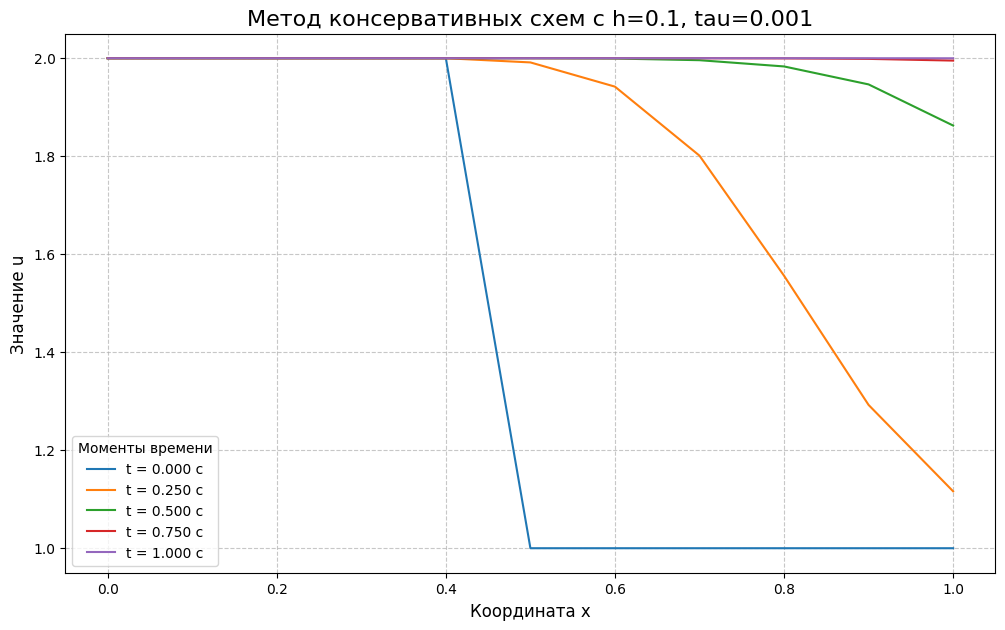

In [330]:
plot_time_snapshots(x_coords=x, t_coords=t, u_solution=u, title="Метод консервативных схем с h=0.1, tau=0.001")

In [331]:
h = 0.05
tau = h / 100
nx = int((b - a) / h + 1)
nt = int((d - c) / tau + 1)

x = [a + i * h for i in range(nx)]
t = [c + i * tau for i in range(nt)]

u = conservative_scheme(x, t, h, tau)

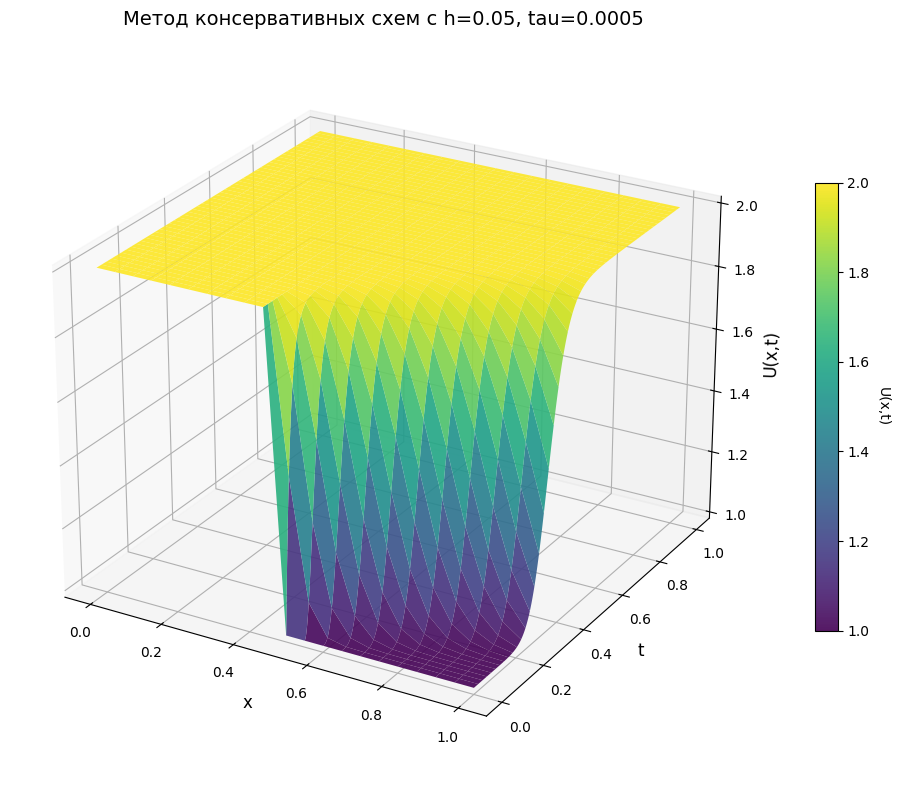

(<Figure size 1200x800 with 2 Axes>,
 <Axes3D: title={'center': 'Метод консервативных схем с h=0.05, tau=0.0005'}, xlabel='x', ylabel='t', zlabel='U(x,t)'>)

In [332]:
plot_3d_surface(
    np.array(x),
    np.array(t),
    np.array(u),
    "Метод консервативных схем с h=0.05, tau=0.0005",
    filename="Метод консервативных схем с h=0.05, tau=0.0005.png"
)

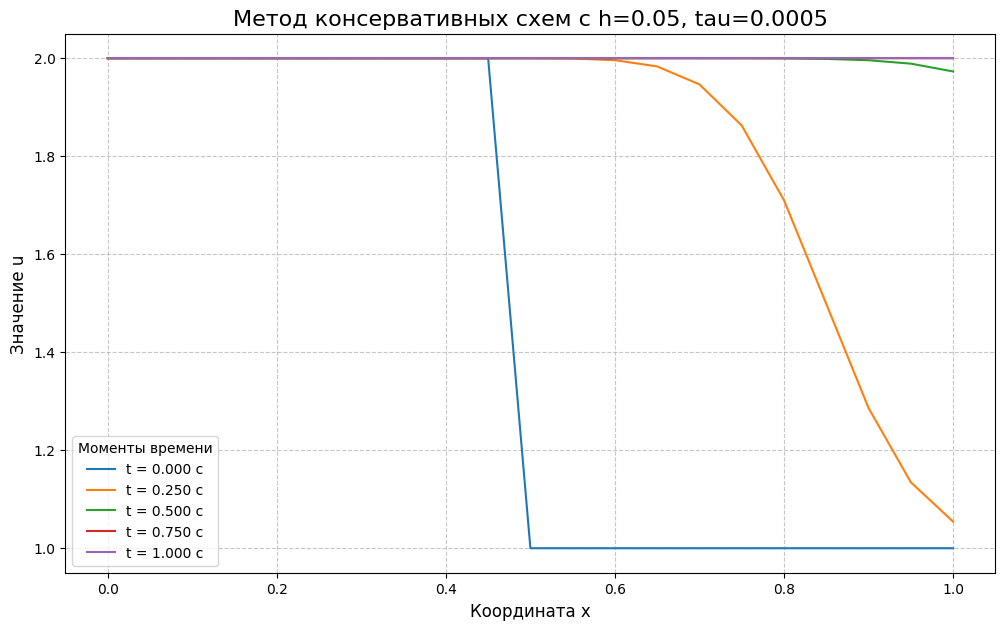

In [333]:
plot_time_snapshots(x_coords=x, t_coords=t, u_solution=u, title="Метод консервативных схем с h=0.05, tau=0.0005")

In [334]:
h = 0.025
tau = h / 100
nx = int((b - a) / h + 1)
nt = int((d - c) / tau + 1)

x = [a + i * h for i in range(nx)]
t = [c + i * tau for i in range(nt)]

u = conservative_scheme(x, t, h, tau)

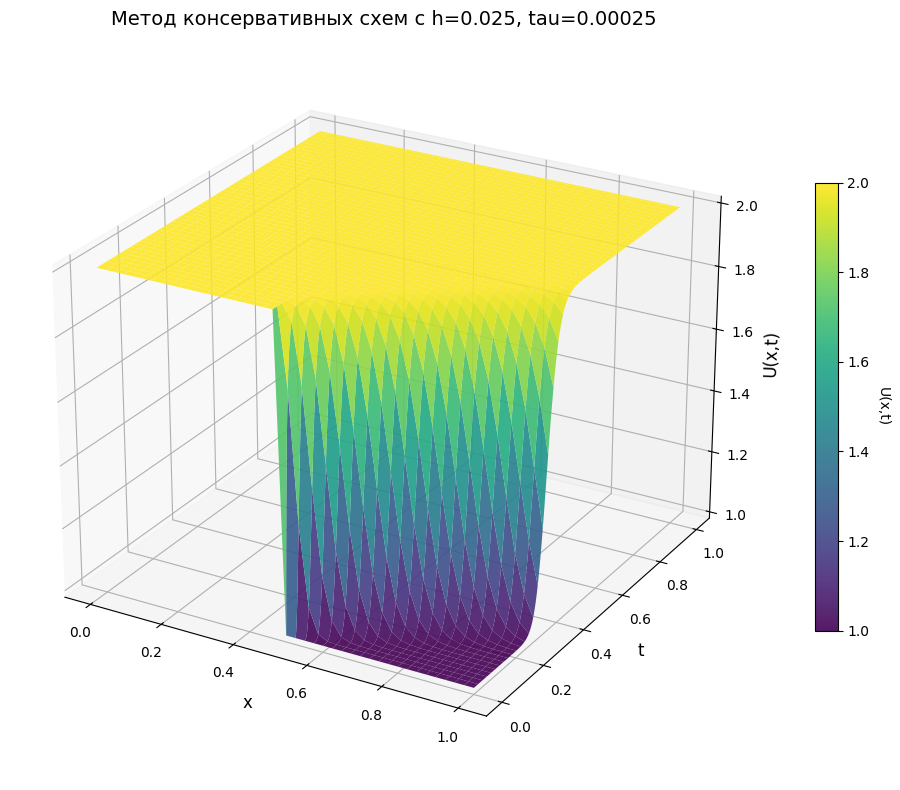

(<Figure size 1200x800 with 2 Axes>,
 <Axes3D: title={'center': 'Метод консервативных схем с h=0.025, tau=0.00025'}, xlabel='x', ylabel='t', zlabel='U(x,t)'>)

In [335]:
plot_3d_surface(
    np.array(x),
    np.array(t),
    np.array(u),
    "Метод консервативных схем с h=0.025, tau=0.00025",
    filename="Метод консервативных схем с h=0.025, tau=0.00025.png"
)

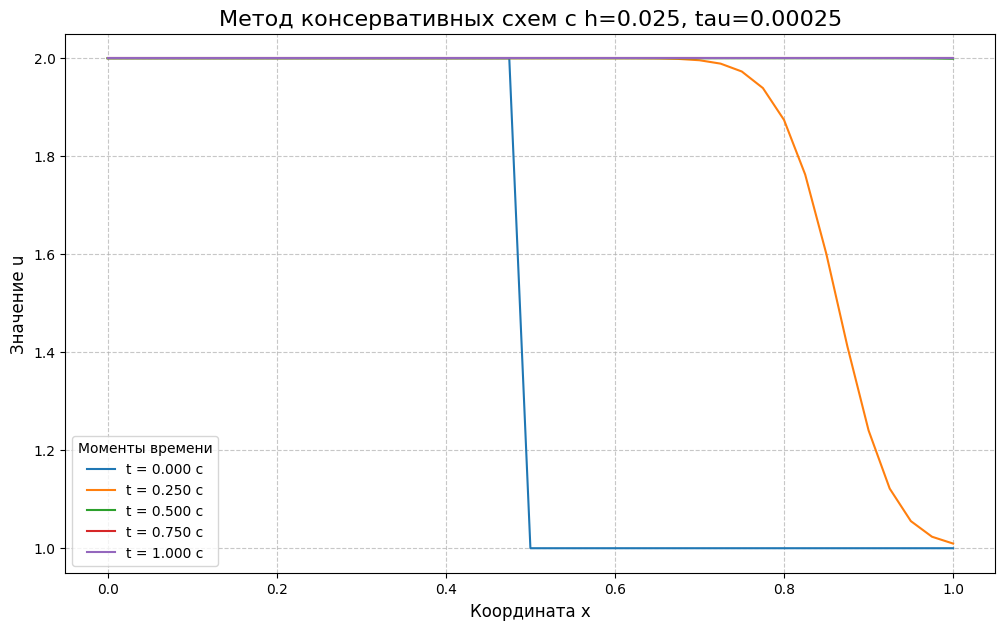

In [336]:
plot_time_snapshots(x_coords=x, t_coords=t, u_solution=u, title="Метод консервативных схем с h=0.025, tau=0.00025")